# Week 1｜Matplotlib 五类科研图表

**目标：**从上到下运行，得到五张常用于论文和实验报告的图。先运行，后修改；不要一开始就试图记住全部语法。

## 0. 导入库与统一风格
每个 Notebook 都把导入语句集中在最前面。

In [11]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
np.random.seed(42)
plt.rcParams['axes.unicode_minus'] = False

## 图 1：折线图——训练与验证损失
横轴是训练轮数，纵轴是损失。一般希望损失下降；若验证损失反而上升，可能是过拟合。

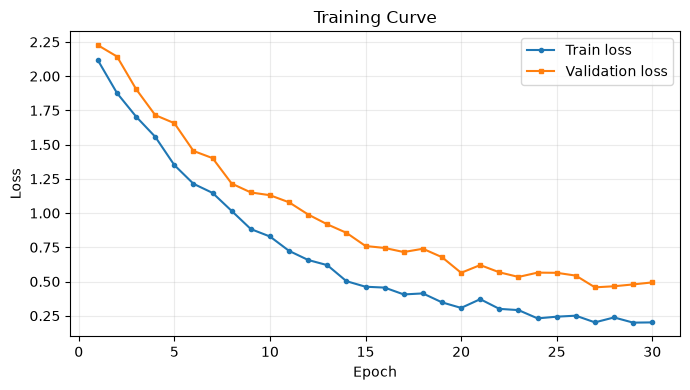

In [2]:
epochs = np.arange(1, 31)
train_loss = 2.2 * np.exp(-0.12 * epochs) + 0.15 + 0.03 * np.random.randn(30)
val_loss = 2.1 * np.exp(-0.10 * epochs) + 0.35 + 0.04 * np.random.randn(30)

plt.figure(figsize=(7, 4))
plt.plot(epochs, train_loss, marker='o', markersize=3, label='Train loss')
plt.plot(epochs, val_loss, marker='s', markersize=3, label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Curve')
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 图 2：混淆矩阵——分类结果
第 i 行表示真实类别，第 j 列表示预测类别。主对角线越大越好。

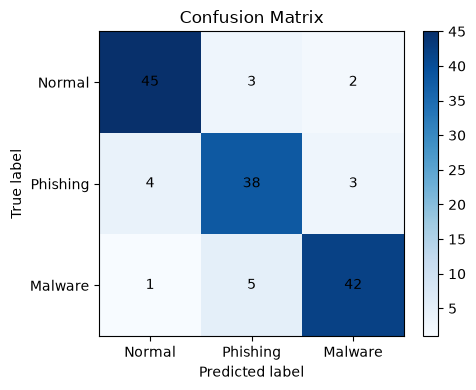

In [10]:
cm = np.array([[45, 3, 2], [4, 38, 3], [1, 5, 42]])
labels = ['Normal', 'Phishing', 'Malware']

fig, ax = plt.subplots(figsize=(5, 4))
image = ax.imshow(cm, cmap='Blues')
fig.colorbar(image, ax=ax)
ax.set_xticks(range(3), labels=labels)
ax.set_yticks(range(3), labels=labels)
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
ax.set_title('Confusion Matrix')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha='center', va='center')
plt.tight_layout()
plt.show()

## 图 3：条形图——模型性能比较
比较不同方法时，横轴放模型名称，纵轴放同一个指标。注意标题与坐标轴必须写清楚。

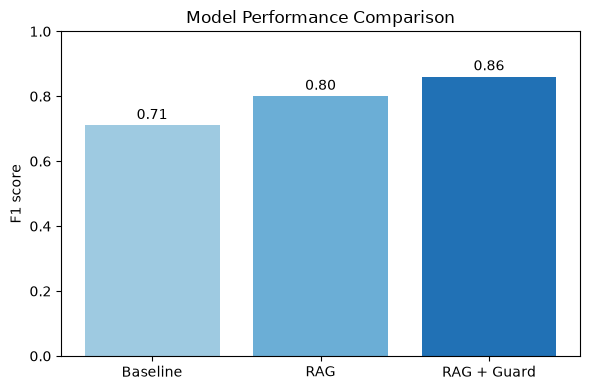

In [4]:
models = ['Baseline', 'RAG', 'RAG + Guard']
f1_scores = [0.71, 0.80, 0.86]
colors = ['#9ecae1', '#6baed6', '#2171b5']

plt.figure(figsize=(6, 4))
bars = plt.bar(models, f1_scores, color=colors)
plt.ylim(0, 1)
plt.ylabel('F1 score')
plt.title('Model Performance Comparison')
for bar, score in zip(bars, f1_scores):
    plt.text(bar.get_x() + bar.get_width()/2, score + 0.02, f'{score:.2f}', ha='center')
plt.tight_layout()
plt.show()

## 图 4：ROC 曲线——二分类阈值权衡
ROC 曲线描述不同判定阈值下的真阳性率（TPR）和假阳性率（FPR）。曲线越靠近左上角越好；虚线代表随机分类器。

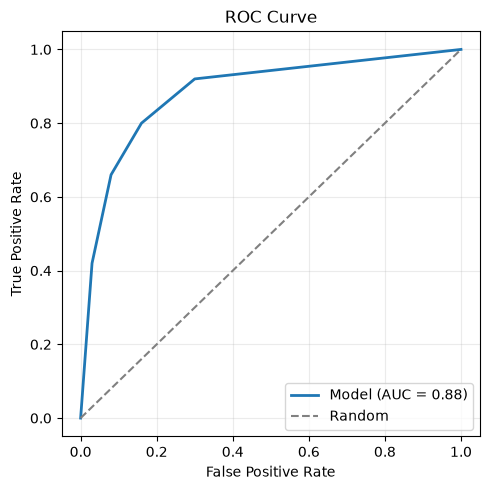

In [13]:
fpr = np.array([0.0, 0.03, 0.08, 0.16, 0.30, 1.0])
tpr = np.array([0.0, 0.42, 0.66, 0.80, 0.92, 1.0])

# 新版 NumPy 中用 trapezoid 计算 ROC 曲线下面积
auc = np.trapezoid(tpr, fpr)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, linewidth=2, label=f'Model (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], '--', color='gray', label='Random')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 图 5：二维特征空间可视化
真实研究中可用 t-SNE 将高维特征降到二维；这里先用人为构造的二维特征学习散点图读法。不同颜色代表不同类别。

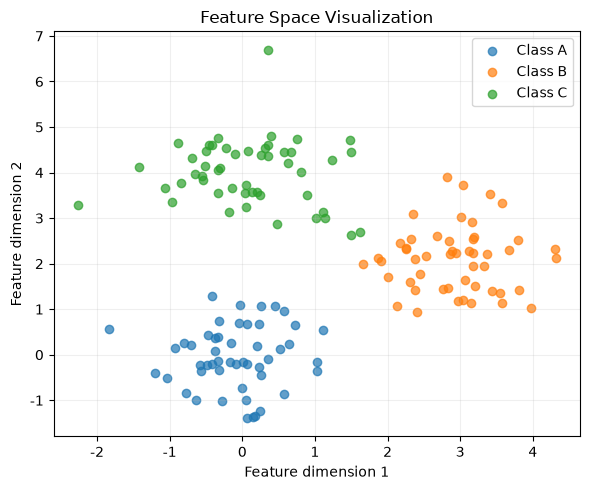

In [14]:
class_a = np.random.randn(50, 2) * 0.7 + np.array([0, 0])
class_b = np.random.randn(50, 2) * 0.7 + np.array([3, 2])
class_c = np.random.randn(50, 2) * 0.7 + np.array([0, 4])

plt.figure(figsize=(6, 5))
plt.scatter(class_a[:, 0], class_a[:, 1], alpha=0.7, label='Class A')
plt.scatter(class_b[:, 0], class_b[:, 1], alpha=0.7, label='Class B')
plt.scatter(class_c[:, 0], class_c[:, 1], alpha=0.7, label='Class C')
plt.xlabel('Feature dimension 1')
plt.ylabel('Feature dimension 2')
plt.title('Feature Space Visualization')
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 练习：做一点自己的修改
任选一张图完成以下任意两项，并在下方新建 Markdown 格记录结果：

- 改标题、颜色或图例位置；
- 将图 3 的 F1 分数替换为你自设的数据；
- 将图 1 的训练轮数从 30 改为 50；
- 使用 `plt.savefig('my_figure.png', dpi=300, bbox_inches='tight')` 保存一张图。

最后按 `Ctrl+S` 保存。